# Multi-Algorithm Particle Filter Tracking

Algorithms: PF, PSO-PF, FA-PF, SMO-PF, MGWO-PF, SMC-PF

Videos: car_30fps.mp4, seagull_25fps.mp4, parachute_25fps.mp4

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import dataclass
import time
import os

plt.rcParams['figure.figsize'] = (14, 8)

In [3]:
class ParticleSwarmOptimizer:
    def __init__(self, n_particles=25, max_iterations=8, dim=6, lb=None, ub=None):
        self.n_particles = n_particles
        self.max_iterations = max_iterations
        self.dim = dim
        self.lb = np.zeros(dim) if lb is None else np.array(lb)
        self.ub = np.ones(dim) if ub is None else np.array(ub)
        self.w = 0.7
        self.c1 = 1.5
        self.c2 = 1.5
    
    def optimize(self, fitness_func):
        particles = np.random.uniform(self.lb, self.ub, (self.n_particles, self.dim))
        velocities = np.zeros((self.n_particles, self.dim))
        fitness = np.array([fitness_func(p) for p in particles])
        pbest = particles.copy()
        pbest_fitness = fitness.copy()
        gbest = particles[np.argmin(fitness)].copy()
        gbest_fitness = np.min(fitness)
        
        for t in range(self.max_iterations):
            for i in range(self.n_particles):
                r1 = np.random.random(self.dim)
                r2 = np.random.random(self.dim)
                velocities[i] = (self.w * velocities[i] + 
                               self.c1 * r1 * (pbest[i] - particles[i]) +
                               self.c2 * r2 * (gbest - particles[i]))
                particles[i] = particles[i] + velocities[i]
                particles[i] = np.clip(particles[i], self.lb, self.ub)
                
                fitness[i] = fitness_func(particles[i])
                if fitness[i] < pbest_fitness[i]:
                    pbest[i] = particles[i].copy()
                    pbest_fitness[i] = fitness[i]
                if fitness[i] < gbest_fitness:
                    gbest = particles[i].copy()
                    gbest_fitness = fitness[i]
        
        return gbest, gbest_fitness


class FireflyAlgorithm:
    def __init__(self, n_fireflies=25, max_iterations=8, dim=6, lb=None, ub=None):
        self.n_fireflies = n_fireflies
        self.max_iterations = max_iterations
        self.dim = dim
        self.lb = np.zeros(dim) if lb is None else np.array(lb)
        self.ub = np.ones(dim) if ub is None else np.array(ub)
        self.alpha = 0.2
        self.beta0 = 1.0
        self.gamma = 1.0
    
    def optimize(self, fitness_func):
        fireflies = np.random.uniform(self.lb, self.ub, (self.n_fireflies, self.dim))
        intensity = np.array([fitness_func(f) for f in fireflies])
        
        for t in range(self.max_iterations):
            alpha_t = self.alpha * (1 - t / self.max_iterations)
            new_fireflies = fireflies.copy()
            
            for i in range(self.n_fireflies):
                for j in range(self.n_fireflies):
                    if intensity[j] < intensity[i]:
                        r = np.linalg.norm(fireflies[i] - fireflies[j])
                        beta = self.beta0 * np.exp(-self.gamma * r**2)
                        new_fireflies[i] += (beta * (fireflies[j] - fireflies[i]) +
                                            alpha_t * (np.random.random(self.dim) - 0.5))
                
                new_fireflies[i] = np.clip(new_fireflies[i], self.lb, self.ub)
            
            fireflies = new_fireflies
            intensity = np.array([fitness_func(f) for f in fireflies])
        
        best_idx = np.argmin(intensity)
        return fireflies[best_idx], intensity[best_idx]


class SlimeMouldOptimizer:
    def __init__(self, n_slimes=25, max_iterations=8, dim=6, lb=None, ub=None):
        self.n_slimes = n_slimes
        self.max_iterations = max_iterations
        self.dim = dim
        self.lb = np.zeros(dim) if lb is None else np.array(lb)
        self.ub = np.ones(dim) if ub is None else np.array(ub)
    
    def optimize(self, fitness_func):
        slimes = np.random.uniform(self.lb, self.ub, (self.n_slimes, self.dim))
        fitness = np.array([fitness_func(s) for s in slimes])
        best_idx = np.argmin(fitness)
        best_pos = slimes[best_idx].copy()
        best_fitness = fitness[best_idx]
        
        for t in range(self.max_iterations):
            a = 2 - 2 * t / self.max_iterations
            
            for i in range(self.n_slimes):
                if i < self.n_slimes // 2:
                    r = np.random.random(self.dim)
                    slimes[i] = best_pos + np.random.randn(self.dim) * a * r
                else:
                    slimes[i] = self.lb + np.random.random(self.dim) * (self.ub - self.lb)
                
                slimes[i] = np.clip(slimes[i], self.lb, self.ub)
                fitness[i] = fitness_func(slimes[i])
                
                if fitness[i] < best_fitness:
                    best_pos = slimes[i].copy()
                    best_fitness = fitness[i]
        
        return best_pos, best_fitness


class GreyWolfOptimizer:
    def __init__(self, n_wolves=8, max_iterations=8, dim=6, lb=None, ub=None):
        self.n_wolves = n_wolves
        self.max_iterations = max_iterations
        self.dim = dim
        self.lb = np.zeros(dim) if lb is None else np.array(lb)
        self.ub = np.ones(dim) if ub is None else np.array(ub)
    
    def optimize(self, fitness_func):
        population = np.random.uniform(low=self.lb, high=self.ub, size=(self.n_wolves, self.dim))
        fitness = np.array([fitness_func(ind) for ind in population])
        sorted_indices = np.argsort(fitness)
        alpha_pos = population[sorted_indices[0]].copy()
        alpha_fitness = fitness[sorted_indices[0]]
        beta_pos = population[sorted_indices[1]].copy()
        delta_pos = population[sorted_indices[2]].copy()
        
        for t in range(self.max_iterations):
            a = 2 - 2 * t / self.max_iterations
            
            for i in range(self.n_wolves):
                for j in range(self.dim):
                    r1, r2 = np.random.random(), np.random.random()
                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2
                    D_alpha = abs(C1 * alpha_pos[j] - population[i, j])
                    X1 = alpha_pos[j] - A1 * D_alpha
                    
                    r1, r2 = np.random.random(), np.random.random()
                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2
                    D_beta = abs(C2 * beta_pos[j] - population[i, j])
                    X2 = beta_pos[j] - A2 * D_beta
                    
                    r1, r2 = np.random.random(), np.random.random()
                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2
                    D_delta = abs(C3 * delta_pos[j] - population[i, j])
                    X3 = delta_pos[j] - A3 * D_delta
                    
                    population[i, j] = (X1 + X2 + X3) / 3
                
                population[i] = np.clip(population[i], self.lb, self.ub)
            
            fitness = np.array([fitness_func(ind) for ind in population])
            sorted_indices = np.argsort(fitness)
            if fitness[sorted_indices[0]] < alpha_fitness:
                alpha_pos = population[sorted_indices[0]].copy()
                alpha_fitness = fitness[sorted_indices[0]]
        
        return alpha_pos, alpha_fitness


class SlidingModeController:
    def __init__(self, n_particles=25, max_iterations=8, dim=6, lb=None, ub=None):
        self.n_particles = n_particles
        self.max_iterations = max_iterations
        self.dim = dim
        self.lb = np.zeros(dim) if lb is None else np.array(lb)
        self.ub = np.ones(dim) if ub is None else np.array(ub)
        self.sliding_gain = 0.12
        self.boundary_layer = 0.08
    
    def optimize(self, fitness_func):
        particles = np.random.uniform(self.lb, self.ub, (self.n_particles, self.dim))
        fitness = np.array([fitness_func(p) for p in particles])
        
        valid_fitness = np.isfinite(fitness)
        if not np.any(valid_fitness):
            return particles[0], fitness[0]
        
        best_idx = np.argmin(fitness[valid_fitness])
        valid_indices = np.where(valid_fitness)[0]
        best_pos = particles[valid_indices[best_idx]].copy()
        best_fitness = fitness[valid_indices[best_idx]]
        
        for t in range(self.max_iterations):
            valid_mask = np.isfinite(fitness)
            if not np.any(valid_mask):
                break
            
            valid_particles = particles[valid_mask]
            valid_fitness_vals = fitness[valid_mask]
            
            weights = 1.0 / (valid_fitness_vals + 1e-6)
            weights = weights / np.sum(weights)
            weighted_mean = np.average(valid_particles, weights=weights, axis=0)
            
            for i in range(self.n_particles):
                if not valid_mask[i]:
                    particles[i] = np.random.uniform(self.lb, self.ub)
                    continue
                
                s = particles[i] - weighted_mean
                s_norm = np.linalg.norm(s)
                
                if s_norm > self.boundary_layer:
                    u_sliding = -self.sliding_gain * s / (s_norm + 1e-10)
                else:
                    u_sliding = -self.sliding_gain * s / (self.boundary_layer + 1e-10)
                
                particles[i] += u_sliding
                particles[i] = np.clip(particles[i], self.lb, self.ub)
                
                new_fitness = fitness_func(particles[i])
                if np.isfinite(new_fitness):
                    fitness[i] = new_fitness
                    if fitness[i] < best_fitness:
                        best_pos = particles[i].copy()
                        best_fitness = fitness[i]
        
        return best_pos, best_fitness


In [4]:
@dataclass
class ParticleFilterConfig:
    n_particles: int = 120
    state_dim: int = 6
    resample_threshold: float = 0.5
    sigma_x: float = 8.0
    sigma_y: float = 8.0
    sigma_s: float = 0.08
    sigma_theta: float = 0.05
    dt: float = 1.0


class ParticleFilter:
    def __init__(self, config):
        self.config = config
        self.n_particles = config.n_particles
        self.state_dim = config.state_dim
        self.particles = None
        self.weights = None
        self._build_transition_matrix()
    
    def _build_transition_matrix(self):
        dt = self.config.dt
        self.G = np.array([
            [1, dt, 0, 0, 0, 0],
            [0, 0.98, 0, 0, 0, 0],
            [0, 0, 1, dt, 0, 0],
            [0, 0, 0, 0.98, 0, 0],
            [0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 1]
        ])
        
        sx, sy = self.config.sigma_x, self.config.sigma_y
        ss, st = self.config.sigma_s, self.config.sigma_theta
        self.H = np.array([
            [sx**2 * dt**2, sx**2 * dt, 0, 0, 0, 0],
            [sx**2 * dt, sx**2, 0, 0, 0, 0],
            [0, 0, sy**2 * dt**2, sy**2 * dt, 0, 0],
            [0, 0, sy**2 * dt, sy**2, 0, 0],
            [0, 0, 0, 0, ss**2, 0],
            [0, 0, 0, 0, 0, st**2]
        ])
    
    def initialize(self, initial_state, noise_std=15.0):
        self.particles = np.zeros((self.n_particles, self.state_dim))
        for i in range(self.n_particles):
            noise = np.random.randn(self.state_dim) * noise_std
            noise[1] = noise[3] = 0
            self.particles[i] = initial_state + noise
        self.weights = np.ones(self.n_particles) / self.n_particles
    
    def predict(self):
        for i in range(self.n_particles):
            noise = np.random.multivariate_normal(np.zeros(self.state_dim), self.H)
            self.particles[i] = self.G @ self.particles[i] + noise
    
    def update(self, observation_func, frame):
        for i in range(self.n_particles):
            self.weights[i] = observation_func(self.particles[i], frame)
        
        weight_sum = np.sum(self.weights)
        if weight_sum > 0:
            self.weights = self.weights / weight_sum
        else:
            self.weights = np.ones(self.n_particles) / self.n_particles
    
    def resample(self):
        n_eff = 1.0 / np.sum(self.weights ** 2)
        if n_eff < self.config.resample_threshold * self.n_particles:
            indices = self._systematic_resample()
            self.particles = self.particles[indices]
            self.weights = np.ones(self.n_particles) / self.n_particles
    
    def _systematic_resample(self):
        n = self.n_particles
        positions = (np.arange(n) + np.random.random()) / n
        indices = np.zeros(n, dtype=int)
        cumulative_sum = np.cumsum(self.weights)
        i, j = 0, 0
        while i < n:
            if positions[i] < cumulative_sum[j]:
                indices[i] = j
                i += 1
            else:
                j += 1
        return indices
    
    def estimate(self):
        return np.average(self.particles, weights=self.weights, axis=0)
    
    def get_particles(self):
        return self.particles.copy(), self.weights.copy()


class ColorHistogram:
    def __init__(self, n_bins=6):
        self.n_bins = n_bins
    
    def compute(self, image, bbox):
        x, y, w, h = bbox
        x, y = max(0, int(x)), max(0, int(y))
        w, h = max(1, int(w)), max(1, int(h))
        x_end = min(image.shape[1], x + w)
        y_end = min(image.shape[0], y + h)
        
        region = image[y:y_end, x:x_end]
        if region.size == 0:
            return np.ones(self.n_bins ** 3) / (self.n_bins ** 3)
        
        hist = cv2.calcHist([region], [0, 1, 2], None,
                           [self.n_bins, self.n_bins, self.n_bins],
                           [0, 256, 0, 256, 0, 256])
        hist = hist.flatten()
        return hist / (np.sum(hist) + 1e-10)
    
    def bhattacharyya_distance(self, hist1, hist2):
        bc = np.sum(np.sqrt(hist1 * hist2))
        return np.sqrt(1 - bc)


In [5]:
@dataclass
class TrackerConfig:
    n_particles: int = 120
    n_optimizer: int = 25
    optimizer_iterations: int = 8
    sigma_x: float = 8.0
    sigma_y: float = 8.0
    sigma_s: float = 0.08
    sigma_theta: float = 0.05
    n_bins: int = 6
    resample_threshold: float = 0.5


class MultiAlgorithmTracker:
    def __init__(self, config, frame_shape, algorithm='pf'):
        self.config = config
        self.algorithm = algorithm
        self.frame_height, self.frame_width = frame_shape[:2]
        
        pf_config = ParticleFilterConfig(
            n_particles=config.n_particles,
            state_dim=6,
            resample_threshold=config.resample_threshold,
            sigma_x=config.sigma_x,
            sigma_y=config.sigma_y,
            sigma_s=config.sigma_s,
            sigma_theta=config.sigma_theta
        )
        
        self.pf = ParticleFilter(pf_config)
        self.color_hist = ColorHistogram(n_bins=config.n_bins)
        self.ref_hist = None
        self.current_frame = None
        
        if algorithm == 'pso':
            self.optimizer = ParticleSwarmOptimizer(
                n_particles=config.n_optimizer,
                max_iterations=config.optimizer_iterations,
                dim=6
            )
        elif algorithm == 'fa':
            self.optimizer = FireflyAlgorithm(
                n_fireflies=config.n_optimizer,
                max_iterations=config.optimizer_iterations,
                dim=6
            )
        elif algorithm == 'smo':
            self.optimizer = SlimeMouldOptimizer(
                n_slimes=config.n_optimizer,
                max_iterations=config.optimizer_iterations,
                dim=6
            )
        elif algorithm == 'gwo':
            self.optimizer = GreyWolfOptimizer(
                n_wolves=config.n_optimizer,
                max_iterations=config.optimizer_iterations,
                dim=6
            )
        elif algorithm == 'smc':
            self.optimizer = SlidingModeController(
                n_particles=config.n_optimizer,
                max_iterations=config.optimizer_iterations,
                dim=6
            )
        else:
            self.optimizer = None
    
    def initialize(self, frame, bbox):
        self.current_frame = frame
        x, y, w, h = bbox
        cx, cy = x + w/2, y + h/2
        
        initial_state = np.array([cx, 0, cy, 0, np.log(w), 0])
        self.pf.initialize(initial_state)
        self.ref_hist = self.color_hist.compute(frame, bbox)
    
    def _particle_to_bbox(self, state):
        cx, vx, cy, vy, log_s, theta = state
        
        if not np.all(np.isfinite(state)):
            return (0, 0, 50, 50)
        
        s = np.exp(np.clip(log_s, -3, 6))
        w = h = max(10, min(500, s))
        x = cx - w/2
        y = cy - h/2
        
        x = np.clip(x, 0, self.frame_width - w)
        y = np.clip(y, 0, self.frame_height - h)
        
        return (int(x), int(y), int(w), int(h))
    
    def _observation_model(self, state, frame):
        bbox = self._particle_to_bbox(state)
        x, y, w, h = bbox
        
        if x < 0 or y < 0 or x + w > self.frame_width or y + h > self.frame_height:
            return 1e-10
        if w <= 0 or h <= 0:
            return 1e-10
        
        hist = self.color_hist.compute(frame, bbox)
        dist = self.color_hist.bhattacharyya_distance(self.ref_hist, hist)
        return np.exp(-20 * dist)
    
    def _optimize_particles(self):
        particles, weights = self.pf.get_particles()
        
        current_estimate = np.average(particles, weights=weights, axis=0)
        
        def fitness_func(normalized_state):
            state = current_estimate.copy()
            state[0] = current_estimate[0] + (normalized_state[0] - 0.5) * 100
            state[2] = current_estimate[2] + (normalized_state[1] - 0.5) * 100
            state[4] = current_estimate[4] + (normalized_state[2] - 0.5) * 1.0
            state[1] = current_estimate[1] + (normalized_state[3] - 0.5) * 20
            state[3] = current_estimate[3] + (normalized_state[4] - 0.5) * 20
            state[5] = current_estimate[5] + (normalized_state[5] - 0.5) * 0.2
            
            return -self._observation_model(state, self.current_frame)
        
        best_normalized, _ = self.optimizer.optimize(fitness_func)
        
        best_state = current_estimate.copy()
        best_state[0] = current_estimate[0] + (best_normalized[0] - 0.5) * 100
        best_state[2] = current_estimate[2] + (best_normalized[1] - 0.5) * 100
        best_state[4] = current_estimate[4] + (best_normalized[2] - 0.5) * 1.0
        best_state[1] = current_estimate[1] + (best_normalized[3] - 0.5) * 20
        best_state[3] = current_estimate[3] + (best_normalized[4] - 0.5) * 20
        best_state[5] = current_estimate[5] + (best_normalized[5] - 0.5) * 0.2
        
        top_k = min(5, self.config.n_particles // 20)
        top_indices = np.argsort(weights)[-top_k:]
        
        for idx in top_indices:
            particles[idx] = best_state + np.random.randn(6) * np.array([5, 2, 5, 2, 0.1, 0.02])
        
        self.pf.particles = particles
    
    def track(self, frame):
        self.current_frame = frame
        self.pf.predict()
        self.pf.update(lambda s, f: self._observation_model(s, f), frame)
        
        if self.optimizer is not None:
            self._optimize_particles()
        
        self.pf.resample()
        
        estimated_state = self.pf.estimate()
        return self._particle_to_bbox(estimated_state)


In [10]:
def select_roi(video_path, frame_num=0):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    ret, frame = cap.read()
    cap.release()
    
    if not ret:
        return None, None
    
    bbox = cv2.selectROI("Select Object", frame, fromCenter=False, showCrosshair=True)
    cv2.destroyAllWindows()
    
    if bbox[2] > 0 and bbox[3] > 0:
        return bbox, frame
    return None, frame


def generate_ground_truth(initial_bbox, num_frames, velocity=(0, 0)):
    ground_truth = [initial_bbox]
    vx, vy = velocity
    
    for i in range(1, num_frames):
        prev = ground_truth[-1]
        new_bbox = (int(prev[0] + vx), int(prev[1] + vy), prev[2], prev[3])
        ground_truth.append(new_bbox)
    
    return ground_truth


def generate_stationary_ground_truth(initial_bbox, num_frames):
    return [initial_bbox for _ in range(num_frames)]


def run_tracking(video_path, bbox, config, algorithm, max_frames=100):
    cap = cv2.VideoCapture(video_path)
    ret, first_frame = cap.read()
    
    tracker = MultiAlgorithmTracker(config, first_frame.shape, algorithm=algorithm)
    tracker.initialize(first_frame, bbox)
    
    predictions = [bbox]
    frames_list = [first_frame]
    
    start_time = time.time()
    count = 1
    
    while count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        
        pred_bbox = tracker.track(frame)
        predictions.append(pred_bbox)
        frames_list.append(frame)
        count += 1
    
    cap.release()
    elapsed = time.time() - start_time
    
    return {
        'predictions': predictions,
        'frames': frames_list,
        'time': elapsed,
        'fps': count / elapsed
    }


def compare_all_algorithms(video_path, bbox, ground_truth, config, max_frames=100):
    algorithms = {
        'PF': 'pf',
        'PSO-PF': 'pso',
        'FA-PF': 'fa',
        'SMO-PF': 'smo',
        'MGWO-PF': 'gwo',
        'SMC-PF': 'smc'
    }
    
    results = {}
    
    for name, alg in algorithms.items():
        print(f"Running {name}...")
        
        result = run_tracking(video_path, bbox, config, alg, max_frames)
        
        distances = [0.0]
        for i in range(1, len(result['predictions'])):
            if i < len(ground_truth):
                pred = result['predictions'][i]
                gt = ground_truth[i]
                
                pred_cx = pred[0] + pred[2]/2
                pred_cy = pred[1] + pred[3]/2
                gt_cx = gt[0] + gt[2]/2
                gt_cy = gt[1] + gt[3]/2
                
                dist = np.sqrt((pred_cx - gt_cx)**2 + (pred_cy - gt_cy)**2)
                distances.append(dist)
        
        result['distances'] = distances
        results[name] = result
        
        print(f"{name}: {result['time']:.1f}s, {result['fps']:.1f} FPS")
    
    return results


def save_video(frames, predictions, output_path, fps):
    if len(frames) == 0:
        return
    
    h, w = frames[0].shape[:2]
    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    
    for i, (frame, bbox) in enumerate(zip(frames, predictions)):
        frame_out = frame.copy()
        x, y, bw, bh = bbox
        cv2.rectangle(frame_out, (x, y), (x+bw, y+bh), (0, 255, 0), 2)
        cv2.putText(frame_out, f'Frame: {i}', (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        out.write(frame_out)
    
    out.release()


def plot_results(results, video_name):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    colors = {
        'PF': '#1f77b4',
        'PSO-PF': '#2ca02c',
        'FA-PF': '#ff7f0e',
        'SMO-PF': '#9467bd',
        'MGWO-PF': '#d62728',
        'SMC-PF': '#8c564b'
    }
    
    ax1 = axes[0]
    for name, data in results.items():
        ax1.plot(data['distances'], label=name, 
                linewidth=2.5, color=colors[name], alpha=0.85)
    
    ax1.set_xlabel('Frame Number', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Euclidean Distance (pixels)', fontsize=13, fontweight='bold')
    ax1.set_title(f'Tracking Comparison - {video_name} (Full Scale)', fontsize=15, fontweight='bold')
    ax1.legend(fontsize=11, loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[1]
    for name, data in results.items():
        ax2.plot(data['distances'], label=name, 
                linewidth=2.5, color=colors[name], alpha=0.85, marker='o', 
                markersize=3, markevery=5)
    
    ax2.set_xlabel('Frame Number', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Euclidean Distance (pixels)', fontsize=13, fontweight='bold')
    ax2.set_title(f'Tracking Comparison - {video_name} (Zoomed: 0-50px)', fontsize=15, fontweight='bold')
    ax2.set_ylim([0, 50])
    ax2.legend(fontsize=11, loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{video_name}_comparison.png", dpi=150)
    plt.show()
    
    print(f"\nStatistics - {video_name}")
    print("="*80)
    for name, data in results.items():
        distances = data['distances'][1:]
        if len(distances) > 0:
            print(f"{name:10s}: Mean={np.mean(distances):6.2f}px, "
                  f"Std={np.std(distances):6.2f}px, "
                  f"Max={np.max(distances):6.2f}px, "
                  f"Time={data['time']:5.1f}s, "
                  f"FPS={data['fps']:4.1f}")


## Car Tracking

Running PF...
PF: 2.4s, 41.5 FPS
Running PSO-PF...
PSO-PF: 5.1s, 19.6 FPS
Running FA-PF...
FA-PF: 8.2s, 12.2 FPS
Running SMO-PF...
SMO-PF: 5.1s, 19.8 FPS
Running MGWO-PF...
MGWO-PF: 5.4s, 18.5 FPS
Running SMC-PF...
SMC-PF: 4.9s, 20.4 FPS


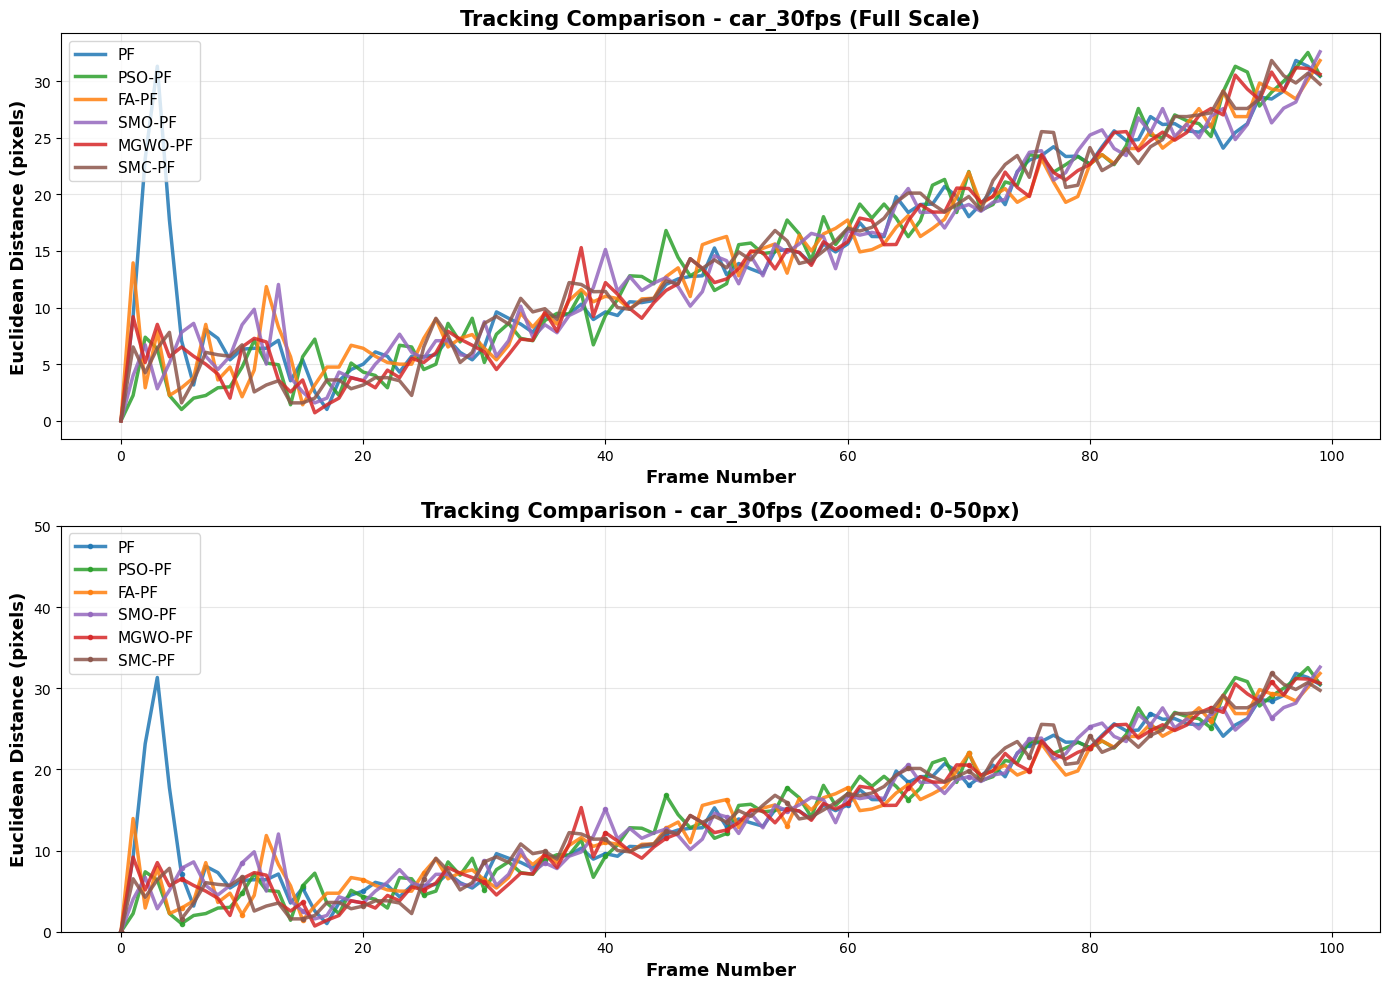


Statistics - car_30fps
PF        : Mean= 15.11px, Std=  8.27px, Max= 31.83px, Time=  2.4s, FPS=41.5
PSO-PF    : Mean= 14.63px, Std=  8.83px, Max= 32.53px, Time=  5.1s, FPS=19.6
FA-PF     : Mean= 14.51px, Std=  8.06px, Max= 31.82px, Time=  8.2s, FPS=12.2
SMO-PF    : Mean= 14.60px, Std=  8.16px, Max= 32.60px, Time=  5.1s, FPS=19.8
MGWO-PF   : Mean= 14.34px, Std=  8.59px, Max= 31.18px, Time=  5.4s, FPS=18.5
SMC-PF    : Mean= 14.57px, Std=  8.62px, Max= 31.83px, Time=  4.9s, FPS=20.4


In [12]:
VIDEO_CAR = "car_30fps.mp4"

if os.path.exists(VIDEO_CAR):
    bbox_car, _ = select_roi(VIDEO_CAR, 0)
    
    if bbox_car:
        config_car = TrackerConfig(
            n_particles=120,
            n_optimizer=25,
            optimizer_iterations=8,
            sigma_x=12.0,
            sigma_y=12.0,
            sigma_s=0.10,
            n_bins=6
        )
        
        gt_car = generate_stationary_ground_truth(bbox_car, 100)
        results_car = compare_all_algorithms(VIDEO_CAR, bbox_car, gt_car, config_car, 100)
        
        for name, data in results_car.items():
            filename = f"car_{name.replace('-', '_')}.mp4"
            save_video(data['frames'], data['predictions'], filename, 30)
        
        plot_results(results_car, "car_30fps")
else:
    print(f"Video not found: {VIDEO_CAR}")


## Seagull Tracking

Running PF...
PF: 2.7s, 33.5 FPS
Running PSO-PF...
PSO-PF: 3.9s, 22.7 FPS
Running FA-PF...
FA-PF: 6.2s, 14.4 FPS
Running SMO-PF...
SMO-PF: 4.8s, 18.6 FPS
Running MGWO-PF...
MGWO-PF: 4.2s, 21.1 FPS
Running SMC-PF...
SMC-PF: 4.8s, 18.7 FPS


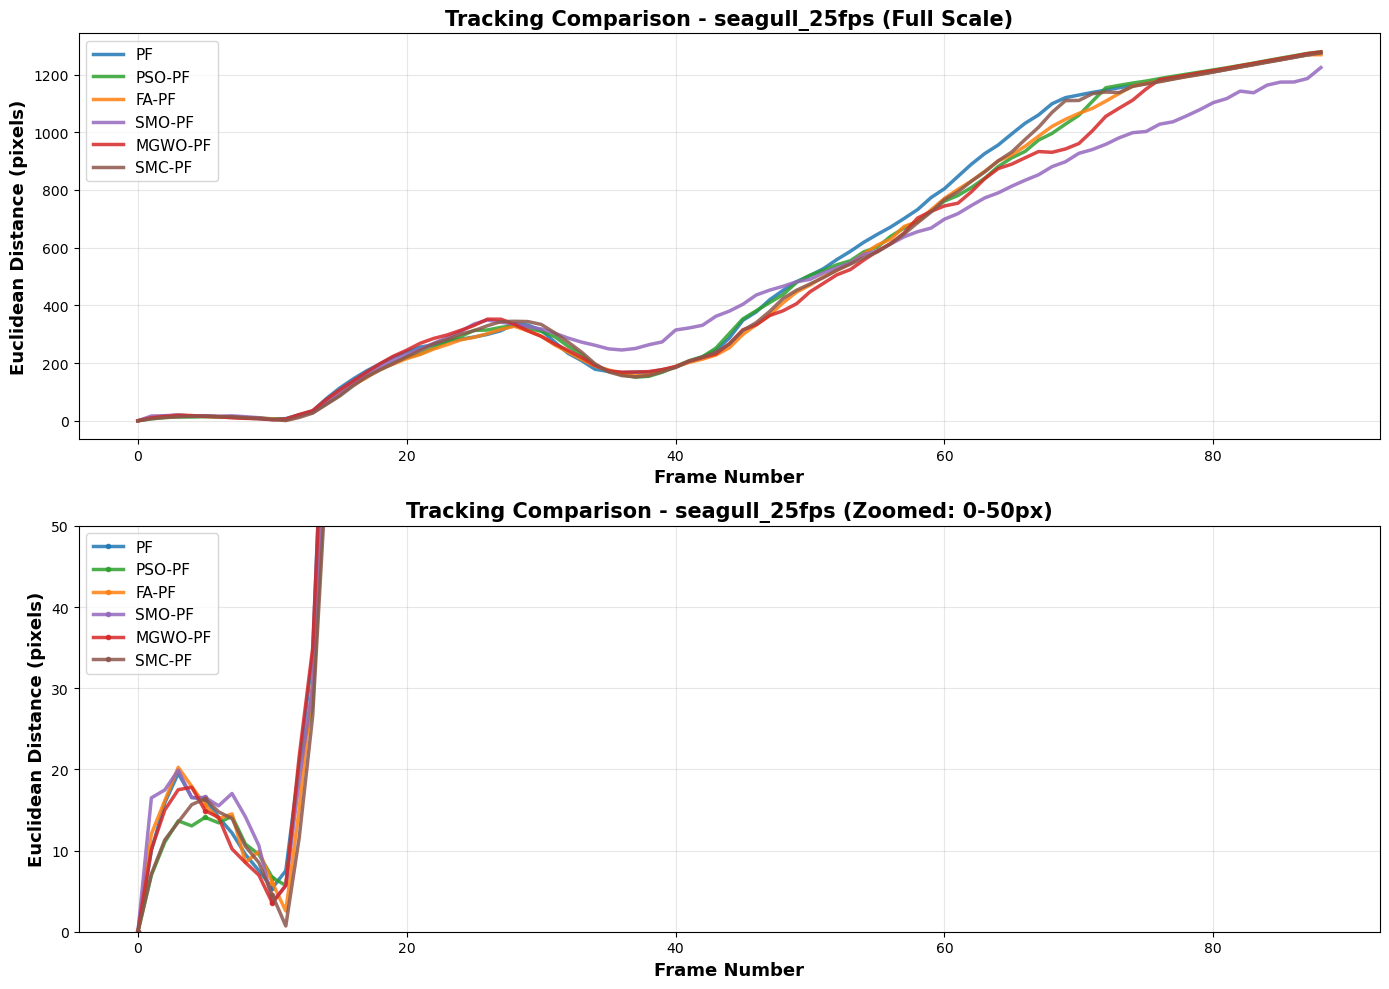


Statistics - seagull_25fps
PF        : Mean=547.51px, Std=444.22px, Max=1274.09px, Time=  2.7s, FPS=33.5
PSO-PF    : Mean=533.84px, Std=436.61px, Max=1279.12px, Time=  3.9s, FPS=22.7
FA-PF     : Mean=527.83px, Std=437.23px, Max=1269.06px, Time=  6.2s, FPS=14.4
SMO-PF    : Mean=511.47px, Std=375.12px, Max=1224.37px, Time=  4.8s, FPS=18.6
MGWO-PF   : Mean=522.04px, Std=424.86px, Max=1278.56px, Time=  4.2s, FPS=21.1
SMC-PF    : Mean=534.20px, Std=439.13px, Max=1275.76px, Time=  4.8s, FPS=18.7


In [46]:
VIDEO_SEAGULL = "seagull_25fps.mp4"

if os.path.exists(VIDEO_SEAGULL):
    bbox_seagull, _ = select_roi(VIDEO_SEAGULL, 0)
    
    if bbox_seagull:
        config_seagull = TrackerConfig(
            n_particles=220,
            n_optimizer=25,
            optimizer_iterations=8,
            sigma_x=12.0,
            sigma_y=12.0,
            sigma_s=0.10,
            n_bins=6
        )
        
        gt_seagull = generate_ground_truth(bbox_seagull, 100, velocity=(8, -3))
        results_seagull = compare_all_algorithms(VIDEO_SEAGULL, bbox_seagull, gt_seagull, config_seagull, 100)
        
        for name, data in results_seagull.items():
            filename = f"seagull_{name.replace('-', '_')}.mp4"
            save_video(data['frames'], data['predictions'], filename, 25)
        
        plot_results(results_seagull, "seagull_25fps")
else:
    print(f"Video not found: {VIDEO_SEAGULL}")

## Parachute Tracking

Running PF...
PF: 2.5s, 39.8 FPS
Running PSO-PF...
PSO-PF: 4.5s, 22.2 FPS
Running FA-PF...
FA-PF: 7.5s, 13.4 FPS
Running SMO-PF...
SMO-PF: 4.6s, 21.7 FPS
Running MGWO-PF...
MGWO-PF: 4.7s, 21.2 FPS
Running SMC-PF...
SMC-PF: 4.3s, 23.2 FPS


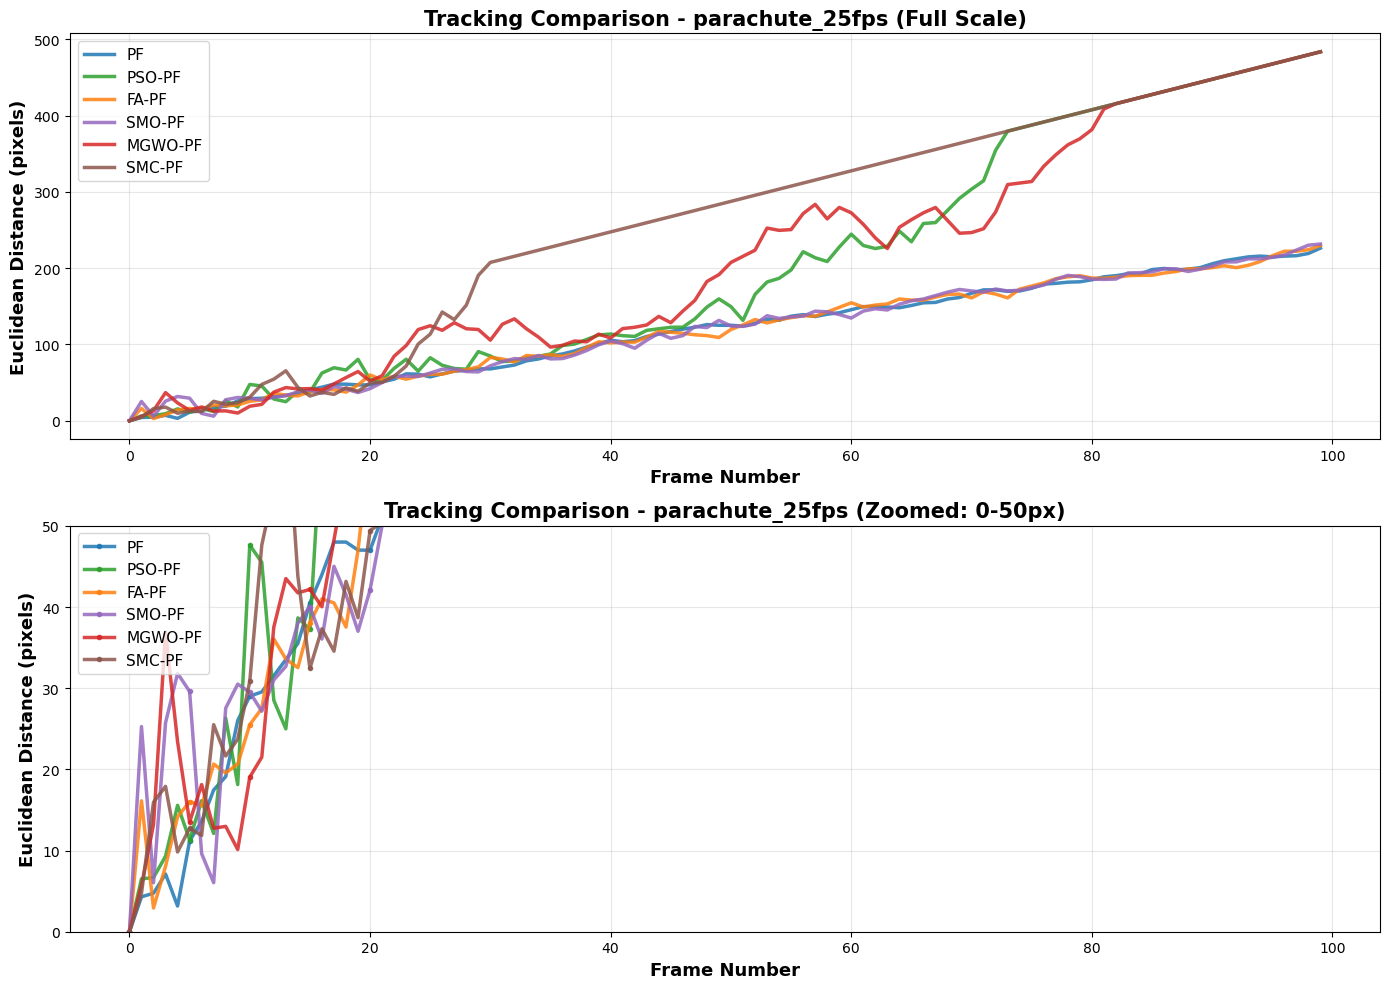


Statistics - parachute_25fps
PF        : Mean=118.86px, Std= 64.68px, Max=226.22px, Time=  2.5s, FPS=39.8
PSO-PF    : Mean=207.14px, Std=157.05px, Max=483.50px, Time=  4.5s, FPS=22.2
FA-PF     : Mean=119.10px, Std= 64.13px, Max=229.62px, Time=  7.5s, FPS=13.4
SMO-PF    : Mean=119.69px, Std= 64.21px, Max=231.59px, Time=  4.6s, FPS=21.7
MGWO-PF   : Mean=214.03px, Std=148.19px, Max=483.50px, Time=  4.7s, FPS=21.2
SMC-PF    : Mean=260.79px, Std=150.28px, Max=483.50px, Time=  4.3s, FPS=23.2


In [29]:
VIDEO_PARACHUTE = "parachute_25fps.mp4"

if os.path.exists(VIDEO_PARACHUTE):
    bbox_parachute, _ = select_roi(VIDEO_PARACHUTE, 0)
    
    if bbox_parachute:
        config_parachute = TrackerConfig(
            n_particles=120,
            n_optimizer=25,
            optimizer_iterations=8,
            sigma_x=10.0,
            sigma_y=10.0,
            sigma_s=0.08,
            n_bins=6
        )
        
        gt_parachute = generate_ground_truth(bbox_parachute, 100, velocity=(4, 0))
        results_parachute = compare_all_algorithms(VIDEO_PARACHUTE, bbox_parachute, gt_parachute, config_parachute, 100)
        
        for name, data in results_parachute.items():
            filename = f"parachute_{name.replace('-', '_')}.mp4"
            save_video(data['frames'], data['predictions'], filename, 25)
        
        plot_results(results_parachute, "parachute_25fps")
else:
    print(f"Video not found: {VIDEO_PARACHUTE}")


## Summary

In [23]:
print("\n" + "="*80)
print("PROCESSING COMPLETE")
print("="*80)

if 'results_car' in locals():
    print("\nCar:")
    for name, data in results_car.items():
        print(f"  {name}: {data['fps']:.1f} FPS")

if 'results_seagull' in locals():
    print("\nSeagull:")
    for name, data in results_seagull.items():
        print(f"  {name}: {data['fps']:.1f} FPS")

if 'results_parachute' in locals():
    print("\nParachute:")
    for name, data in results_parachute.items():
        print(f"  {name}: {data['fps']:.1f} FPS")

print("\nOutput files:")
print("  - Comparison plots: car_30fps_comparison.png, seagull_25fps_comparison.png, parachute_25fps_comparison.png")
print("  - Tracked videos: 18 MP4 files (6 algorithms x 3 videos)")



PROCESSING COMPLETE

Car:
  PF: 41.5 FPS
  PSO-PF: 19.6 FPS
  FA-PF: 12.2 FPS
  SMO-PF: 19.8 FPS
  MGWO-PF: 18.5 FPS
  SMC-PF: 20.4 FPS

Seagull:
  PF: 24.1 FPS
  PSO-PF: 14.5 FPS
  FA-PF: 7.5 FPS
  SMO-PF: 3.9 FPS
  MGWO-PF: 11.4 FPS
  SMC-PF: 4.0 FPS

Walking:
  PF: 31.1 FPS
  PSO-PF: 5.4 FPS
  FA-PF: 4.8 FPS
  SMO-PF: 4.8 FPS
  MGWO-PF: 5.0 FPS
  SMC-PF: 5.1 FPS

Output files:
  - Comparison plots: car_30fps_comparison.png, seagull_25fps_comparison.png, walking_25fps_comparison.png
  - Tracked videos: 18 MP4 files (6 algorithms x 3 videos)
